In [ ]:
pip install keras-tuner

In [ ]:
import pandas as pd
import os
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import keras_tuner as kt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.utils import class_weight

In [ ]:
splits = {'train': 'data/train-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}
train_df = pd.read_parquet("hf://datasets/TimSchopf/medical_abstracts/" + splits["train"])
test_df = pd.read_parquet("hf://datasets/TimSchopf/medical_abstracts/" + splits["test"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
train_df

,condition_label,medical_abstract
0,5,Tissue changes around loose prostheses. A cani...
1,1,Neuropeptide Y and neuron-specific enolase lev...
2,2,"Sexually transmitted diseases of the colon, re..."
3,1,Lipolytic factors associated with murine and h...
4,3,Does carotid restenosis predict an increased r...
...,...,...
11545,1,Epirubicin at two dose levels with prednisolon...
11546,1,Four and a half year follow up of women with d...
11547,5,Safety of the transbronchial biopsy in outpati...
11548,3,Interictal spikes and hippocampal somatostatin...


In [ ]:
os.environ['KERAS_BACKEND'] = 'tensorflow'

In [ ]:
keras.utils.set_random_seed(42)

In [ ]:
train_df['condition_label'].value_counts() / train_df.shape[0]

,count
condition_label,
5,0.332814
1,0.219048
4,0.211342
3,0.133333
2,0.103463


In [ ]:
y_train = pd.get_dummies(train_df['condition_label'],dtype="int").to_numpy()
y_test = pd.get_dummies(test_df['condition_label'], dtype="int").to_numpy()

In [ ]:
y_train

array([[0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 1],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 0, 1]])

## Unigram - 0.5114 accuracy

In [ ]:
keras.utils.set_random_seed(42)

In [ ]:
max_tokens = 5000
text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="count")

In [ ]:
text_vectorization.adapt(train_df['medical_abstract'])

In [ ]:
X_train = text_vectorization(train_df['medical_abstract'])
X_test = text_vectorization(test_df['medical_abstract'])

In [ ]:
inputs = keras.layers.Input(shape=(max_tokens, ))
x = keras.layers.Dense(128, activation="relu")(inputs)
x = keras.layers.Dropout(0.5)(x)
x = keras.layers.Dense(64, activation="relu")(x)
outputs = keras.layers.Dense(5, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,709 (2.47 MB)

 Trainable params: 648,709 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
model.fit(
    x=X_train,
    y=y_train,
    validation_split=0.2,   # 20% of training data used as validation
    epochs=10,
    batch_size=32
)

Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4893 - loss: 1.2551 - val_accuracy: 0.5779 - val_loss: 1.0487
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6240 - loss: 0.9341 - val_accuracy: 0.5814 - val_loss: 1.0357
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6795 - loss: 0.7895 - val_accuracy: 0.5554 - val_loss: 1.0981
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7205 - loss: 0.6857 - val_accuracy: 0.5420 - val_loss: 1.1844
Epoch 5/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7483 - loss: 0.6263 - val_accuracy: 0.5307 - val_loss: 1.2696
Epoch 6/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7703 - loss: 0.5703 - val_accuracy: 0.5247 - val_loss: 1.4181
Epoch 7/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7870 - loss: 0.5222 - val_accuracy: 0.5143 - val_loss: 1.4753
Epoch 8/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7942 - loss: 0.4967 - val_accuracy: 0

In [ ]:
model.evaluate(x=X_test, y=y_test, verbose=0)

[1.5818153619766235, 0.511426568031311]

In [ ]:
# 1. Predict on the test data
y_pred_probs = model.predict(X_test)

# 2. Convert probabilities to class indices (0, 1, 2, 3, or 4)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Convert your ground truth (y_test) to indices if it's currently one-hot encoded
y_true = np.argmax(y_test, axis=1)

# 4. Print the detailed report
# Replace the names below with your actual medical condition names if you have them
target_names = ['Condition 1', 'Condition 2', 'Condition 3', 'Condition 4', 'Condition 5']
print(classification_report(y_true, y_pred, target_names=target_names))

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

 Condition 1       0.62      0.65      0.64       633
 Condition 2       0.41      0.43      0.42       299
 Condition 3       0.47      0.48      0.47       385
 Condition 4       0.59      0.64      0.62       610
 Condition 5       0.42      0.38      0.40       961

    accuracy                           0.51      2888
   macro avg       0.50      0.52      0.51      2888
weighted avg       0.51      0.51      0.51      2888



## Class weight - 0.5291 accuracy

In [ ]:
keras.utils.set_random_seed(42)

In [ ]:

# Convert y_train back to integers if it is one-hot encoded
y_integers = np.argmax(y_train, axis=1)

# Calculate weights
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_integers),
    y=y_integers
)

# Convert to a dictionary for Keras: {0: weight0, 1: weight1, ...}
class_weight_dict = dict(enumerate(weights))

print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(0.9130434782608695), 1: np.float64(1.9330543933054394), 2: np.float64(1.5), 3: np.float64(0.9463334698893896), 4: np.float64(0.600936524453694)}


In [ ]:
max_tokens = 5000
text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="count")

In [ ]:
text_vectorization.adapt(train_df['medical_abstract'])

In [ ]:
X_train = text_vectorization(train_df['medical_abstract'])
X_test = text_vectorization(test_df['medical_abstract'])

In [ ]:
inputs = keras.layers.Input(shape=(max_tokens, ))
x = keras.layers.Dense(128, activation="relu")(inputs)
x = keras.layers.Dropout(0.5)(x)
x = keras.layers.Dense(64, activation="relu")(x)
outputs = keras.layers.Dense(5, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,709 (2.47 MB)

 Trainable params: 648,709 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
model.fit(
    x=X_train,
    y=y_train,
    validation_split=0.2,   # 20% of training data used as validation
    epochs=10,
    batch_size=32,
    class_weight=class_weight_dict
)

Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4610 - loss: 1.2700 - val_accuracy: 0.5502 - val_loss: 1.1119
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6121 - loss: 0.9025 - val_accuracy: 0.5749 - val_loss: 1.1022
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6724 - loss: 0.7520 - val_accuracy: 0.5662 - val_loss: 1.1904
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6997 - loss: 0.6637 - val_accuracy: 0.5515 - val_loss: 1.2816
Epoch 5/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7259 - loss: 0.6022 - val_accuracy: 0.5494 - val_loss: 1.2829
Epoch 6/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7496 - loss: 0.5554 - val_accuracy: 0.5420 - val_loss: 1.3520
Epoch 7/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7716 - loss: 0.5083 - val_accuracy: 0.5355 - val_loss: 1.4338
Epoch 8/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7800 - loss: 0.4810 - val_accuracy: 0.

In [ ]:
model.evaluate(x=X_test, y=y_test, verbose=0)

[1.5682185888290405, 0.5290858745574951]

## Bigram - 0.5020 accuracy

In [ ]:
keras.utils.set_random_seed(42)

In [ ]:
text_vectorization = keras.layers.TextVectorization(
    ngrams=2,
    max_tokens=20000,
    output_mode="count",
)

In [ ]:
text_vectorization.adapt(train_df['medical_abstract'])

In [ ]:
X_train = text_vectorization(train_df['medical_abstract'])
X_test = text_vectorization(test_df['medical_abstract'])

In [ ]:
inputs = keras.layers.Input(shape=(20000, ))
x = keras.layers.Dense(128, activation="relu")(inputs)
x = keras.layers.Dropout(0.5)(x) # Prevents overfitting
x = keras.layers.Dense(64, activation="relu")(x)
outputs = keras.layers.Dense(5, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     2,560,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,568,709 (9.80 MB)

 Trainable params: 2,568,709 (9.80 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
model.fit(x=X_train,
          y=y_train,
          validation_split=0.2,
          epochs=10,
          batch_size=32)

Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4707 - loss: 1.2898 - val_accuracy: 0.5693 - val_loss: 1.0543
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6163 - loss: 0.9585 - val_accuracy: 0.5597 - val_loss: 1.0509
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6861 - loss: 0.8024 - val_accuracy: 0.5463 - val_loss: 1.1490
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7215 - loss: 0.7026 - val_accuracy: 0.5264 - val_loss: 1.1974
Epoch 5/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7576 - loss: 0.6341 - val_accuracy: 0.5281 - val_loss: 1.2980
Epoch 6/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7728 - loss: 0.5829 - val_accuracy: 0.5234 - val_loss: 1.3711
Epoch 7/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7848 - loss: 0.5482 - val_accuracy: 0.5147 - val_loss: 1.4754
Epoch 8/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7953 - loss: 0.5167 - val_accuracy: 0

In [ ]:
model.evaluate(x=X_test, y=y_test, verbose=0)

[1.6036291122436523, 0.502077579498291]

## tf_idf - 0.5087 accuracy

In [ ]:
keras.utils.set_random_seed(42)

In [ ]:
text_vectorization = keras.layers.TextVectorization(
    ngrams=1,
    max_tokens=5000,
    output_mode="tf_idf",
)

In [ ]:
text_vectorization.adapt(train_df['medical_abstract'])

In [ ]:
X_train = text_vectorization(train_df['medical_abstract'])
X_test = text_vectorization(test_df['medical_abstract'])

In [ ]:
inputs = keras.layers.Input(shape=(5000, ))
x = keras.layers.Dense(128, activation="relu")(inputs)
x = keras.layers.Dropout(0.5)(x) # Prevents overfitting
x = keras.layers.Dense(64, activation="relu")(x)
outputs = keras.layers.Dense(5, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,709 (2.47 MB)

 Trainable params: 648,709 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
model.fit(x=X_train,
          y=y_train,
          validation_split=0.2,
          epochs=10,
          batch_size=32)

Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4623 - loss: 1.3664 - val_accuracy: 0.5615 - val_loss: 1.1164
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6044 - loss: 0.9960 - val_accuracy: 0.5610 - val_loss: 1.1125
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6618 - loss: 0.8589 - val_accuracy: 0.5455 - val_loss: 1.1788
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7081 - loss: 0.7639 - val_accuracy: 0.5346 - val_loss: 1.2198
Epoch 5/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7289 - loss: 0.6948 - val_accuracy: 0.5286 - val_loss: 1.3097
Epoch 6/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7500 - loss: 0.6429 - val_accuracy: 0.5169 - val_loss: 1.3734
Epoch 7/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7639 - loss: 0.6046 - val_accuracy: 0.5147 - val_loss: 1.4144
Epoch 8/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7769 - loss: 0.5761 - val_accuracy: 0.

In [ ]:
model.evaluate(x=X_test, y=y_test, verbose=0)

[1.5319294929504395, 0.5086565017700195]

## Parameter tunning - 0.58 accuracy

In [ ]:
keras.utils.set_random_seed(42)

In [ ]:
def build_model(hp):
    inputs = keras.layers.Input(shape=(max_tokens,))

    # Tune the number of units in the first Dense layer
    # It will test values from 32 to 512, stepping by 32
    hp_units = hp.Int('units', min_value=32, max_value=512, step=32)
    x = keras.layers.Dense(units=hp_units, activation='relu')(inputs)

    # Tune the dropout rate
    hp_dropout = hp.Float('dropout', min_value=0.0, max_value=0.5, step=0.1)
    x = keras.layers.Dropout(hp_dropout)(x)

    outputs = keras.layers.Dense(5, activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='my_tuning_dir',
    project_name='medical_bow_tuning'
)

tuner.search(X_train, y_train, epochs=10, validation_split=0.2, class_weight=class_weight_dict)

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]

Reloading Tuner from my_tuning_dir/medical_bow_tuning/tuner0.json


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
best_model.evaluate(x=X_test, y=y_test, verbose=0)

[1.3537505865097046, 0.5515928268432617]

In [ ]:
best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │       480,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 480,581 (1.83 MB)

 Trainable params: 480,581 (1.83 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

best_dropout = best_hps.get('dropout')
best_lr = best_hps.get('learning_rate')
best_units = best_hps.get('units')

print(f"Best Dropout Rate: {best_dropout}")
print(f"Best Learning Rate: {best_lr}")
print(f"Best Units: {best_units}")

Best Dropout Rate: 0.0
Best Learning Rate: 0.001
Best Units: 96


In [ ]:
y_pred_probs = best_model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.argmax(y_test, axis=1)

target_names = ['Condition 0', 'Condition 1', 'Condition 2', 'Condition 3', 'Condition 4']
print(classification_report(y_true, y_pred, target_names=target_names,digits=4))

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

 Condition 0     0.6371    0.7488    0.6885       633
 Condition 1     0.4370    0.3478    0.3873       299
 Condition 2     0.5176    0.5351    0.5262       385
 Condition 3     0.6404    0.7066    0.6719       610
 Condition 4     0.4659    0.4048    0.4332       961

    accuracy                         0.5554      2888
   macro avg     0.5396    0.5486    0.5414      2888
weighted avg     0.5442    0.5554    0.5472      2888



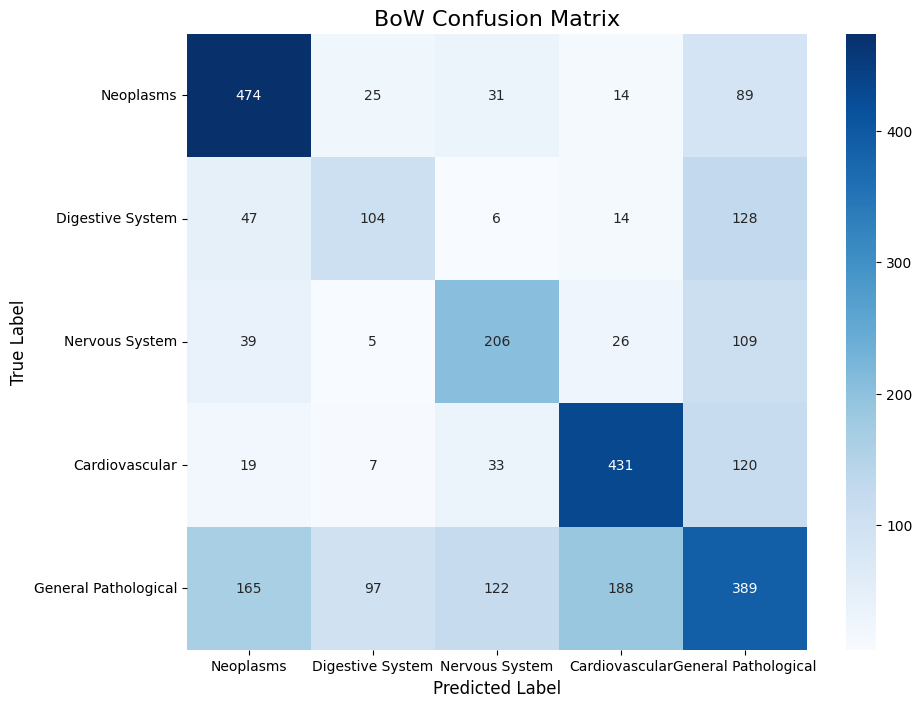

In [ ]:
def plot_medical_cm(y_true, y_pred, class_names):
    """
    Plots a clean, professional heatmap for medical classification results.
    """
    cm = confusion_matrix(y_true, y_pred)

    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title('BoW Confusion Matrix', fontsize=16)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.show()

target_names = ['Neoplasms', 'Digestive System', 'Nervous System', 'Cardiovascular', 'General Pathological']
plot_medical_cm(y_true, y_pred, target_names)

In [ ]:
stop_early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
tuner.search(X_train, y_train, epochs=50, validation_split=0.2, callbacks=[stop_early])